# Metrics Analysis

In this notebook I organize the results from `06-evaluation.ipynb` into cleaner tables and plots. The goal is not to recompute the explanations, but to understand how the existing metrics rank the nine XAI methods.

Main question: **do the objective metrics agree, or do they reward different properties of the explanations?**

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "artifacts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
RESULTS_DIR = PROJECT_ROOT / "docs" / "results"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures" / "metrics-analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EVALUATION_PATH = ARTIFACTS_DIR / "generated-explanations" / "evaluation.json"
GENERATED_DIR = ARTIFACTS_DIR / "generated-explanations"

MODEL = "TANet"
DATASETS = ["EtriActivity3D", "Kinetics400"]

METHODS = [
    "3D-Kernel-SHAP-NEW",
    "3D-LIME-NEW",
    "3D-RISE-NEW",
    "3D-Sampled-Occl-Sens-NEW",
    "LV-LOCO-NEW",
    "LV-Univ-Pred-NEW",
    "SaliencyTubes",
    "AOSA",
    "GradCAM",
]

DISPLAY_NAMES = {
    "3D-Kernel-SHAP-NEW": "3D-Kernel-SHAP",
    "3D-LIME-NEW": "3D-LIME",
    "3D-RISE-NEW": "3D-RISE",
    "3D-Sampled-Occl-Sens-NEW": "3D-Sampled-Occl-Sens",
    "LV-LOCO-NEW": "LV-LOCO",
    "LV-Univ-Pred-NEW": "LV-Univ-Pred",
    "SaliencyTubes": "SaliencyTubes",
    "AOSA": "AOSA",
    "GradCAM": "GradCAM",
}

# Direction used when ranking methods. Lower rank is better.
METRIC_DIRECTIONS = {
    "deletion_auc": "lower",
    "insertion_auc": "higher",
    "avg_drop": "lower",
    "pointing_game": "higher",
    "iou50": "higher",
    "iou_value": "higher",
    "runtime_seconds": "lower",
}

plt.rcParams.update({"font.size": 11})

## Load Results

The experiment I am analysing here uses one model (`TANet`), two datasets, 30 videos per dataset, and 9 explanation methods. The metric values are already saved in `evaluation.json`.

In [2]:
with EVALUATION_PATH.open("r", encoding="utf-8") as f:
    raw_results = json.load(f)

missing = []
for dataset in DATASETS:
    if dataset not in raw_results:
        missing.append(dataset)
        continue
    if MODEL not in raw_results[dataset]:
        missing.append(f"{dataset}/{MODEL}")
        continue
    for method in METHODS:
        if method not in raw_results[dataset][MODEL]:
            missing.append(f"{dataset}/{MODEL}/{method}")

if missing:
    raise ValueError(f"Missing expected results: {missing}")

scope = []
for dataset in DATASETS:
    first_method = raw_results[dataset][MODEL][METHODS[0]]
    n_videos = len(first_method["deletion"]["auc"])
    scope.append({"dataset": dataset, "model": MODEL, "methods": len(METHODS), "videos": n_videos})

scope_df = pd.DataFrame(scope)
scope_df

,dataset,model,methods,videos
0,EtriActivity3D,TANet,9,30
1,Kinetics400,TANet,9,30


## Tidy Metrics Table

I convert the nested JSON structure into a table with one row per video, dataset, and method. For the IoU metrics, I keep the same idea as the previous notebook: choose the threshold that gives the best average result for each method and dataset.

In [3]:
def _as_float(value):
    if value is None:
        return np.nan
    return float(value)


def best_threshold(metric_dict, key):
    """Choose the threshold that gives the highest average value."""
    threshold_means = {}
    for threshold, values in metric_dict[key].items():
        numeric_values = [_as_float(v) for v in values]
        threshold_means[threshold] = np.nanmean(numeric_values)
    return max(threshold_means, key=threshold_means.get)


def flatten_metrics(results):
    rows = []
    threshold_rows = []

    for dataset in DATASETS:
        for method in METHODS:
            method_results = results[dataset][MODEL][method]
            iou50_threshold = best_threshold(method_results["iou"], "th-50")
            iou_value_threshold = best_threshold(method_results["iou"], "value")

            threshold_rows.append({
                "dataset": dataset,
                "model": MODEL,
                "method": method,
                "method_display": DISPLAY_NAMES[method],
                "iou50_threshold": iou50_threshold,
                "iou_value_threshold": iou_value_threshold,
            })

            n_videos = len(method_results["deletion"]["auc"])
            for video_idx in range(n_videos):
                rows.append({
                    "dataset": dataset,
                    "model": MODEL,
                    "method": method,
                    "method_display": DISPLAY_NAMES[method],
                    "video_idx": video_idx,
                    "deletion_auc": _as_float(method_results["deletion"]["auc"][video_idx]),
                    "insertion_auc": _as_float(method_results["insertion"]["auc"][video_idx]),
                    "avg_drop": _as_float(method_results["drop"][video_idx]),
                    "pointing_game": float(bool(method_results["pointing-game"][video_idx])),
                    "iou50": float(bool(method_results["iou"]["th-50"][iou50_threshold][video_idx])),
                    "iou_value": _as_float(method_results["iou"]["value"][iou_value_threshold][video_idx]),
                })

    return pd.DataFrame(rows), pd.DataFrame(threshold_rows)


metrics_df, selected_iou_thresholds = flatten_metrics(raw_results)
metrics_df.to_csv(RESULTS_DIR / "metrics_per_video.csv", index=False)
selected_iou_thresholds.to_csv(RESULTS_DIR / "selected_iou_thresholds.csv", index=False)

metrics_df.head()

,dataset,model,method,method_display,video_idx,deletion_auc,insertion_auc,avg_drop,pointing_game,iou50,iou_value
0,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0,0.032272,0.979946,81.433276,1.0,0.0,0.073712
1,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,1,0.028884,0.995008,16.392034,1.0,0.0,0.070977
2,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,2,0.027002,0.976799,63.213953,1.0,1.0,0.579722
3,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,3,0.013604,0.683879,44.272689,1.0,1.0,0.390767
4,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,4,0.130559,0.924136,27.182446,0.0,0.0,0.057879


## Runtime Table

The runtime values are stored as text files inside the generated artifacts. For `GradCAM`, the available timing file is the same one used for `SaliencyTubes`, so I keep that convention here.

In [4]:
# The file names are not fully consistent across methods, so I map them here.
def time_file_for_method(method):
    if method == "GradCAM":
        return "SaliencyTubes-time.txt"
    if method == "SaliencyTubes":
        return "SaliencyTubes-time.txt"
    if method == "AOSA":
        return "AOSA-time.txt"
    return f"{method}-time-16x112x112.txt"


def collect_runtime_rows():
    rows = []
    for dataset in DATASETS:
        labels_root = GENERATED_DIR / dataset / "data-labels" / MODEL
        for method in METHODS:
            filename = time_file_for_method(method)
            for time_path in labels_root.glob(f"*/*/{filename}"):
                video_name = time_path.parent.name
                video_class = time_path.parent.parent.name
                try:
                    value = float(time_path.read_text().strip())
                except ValueError:
                    value = np.nan
                rows.append({
                    "dataset": dataset,
                    "model": MODEL,
                    "method": method,
                    "method_display": DISPLAY_NAMES[method],
                    "video_class": video_class,
                    "video_name": video_name,
                    "runtime_seconds": value,
                })
    return pd.DataFrame(rows)


runtime_df = collect_runtime_rows()
runtime_df.to_csv(RESULTS_DIR / "runtime_per_video.csv", index=False)
runtime_df.groupby(["dataset", "method_display"])["runtime_seconds"].agg(["count", "mean", "std"]).round(3).head(12)

count     mean    std
dataset        method_display                             
EtriActivity3D 3D-Kernel-SHAP           30  449.150  2.005
               3D-LIME                  30  442.550  2.048
               3D-RISE                  30  440.134  2.354
               3D-Sampled-Occl-Sens     30  473.745  1.949
               AOSA                     30   75.274  0.889
               GradCAM                  30    1.805  0.598
               LV-LOCO                  30   97.183  7.068
               LV-Univ-Pred             30   96.886  7.062
               SaliencyTubes            30    1.805  0.598
Kinetics400    3D-Kernel-SHAP           30  469.972  4.027
               3D-LIME                  30  443.452  1.322
               3D-RISE                  30  440.947  1.533

## Mean and Standard Deviation

This table gives the mean and standard deviation for each method on each dataset. This is the main table I will use for the written analysis.

In [5]:
metric_columns = ["deletion_auc", "insertion_auc", "avg_drop", "pointing_game", "iou50", "iou_value"]

quality_summary = (
    metrics_df
    .groupby(["dataset", "model", "method", "method_display"])[metric_columns]
    .agg(["mean", "std", "count"])
)
quality_summary.columns = [f"{metric}_{stat}" for metric, stat in quality_summary.columns]
quality_summary = quality_summary.reset_index()

runtime_summary = (
    runtime_df
    .groupby(["dataset", "model", "method", "method_display"])["runtime_seconds"]
    .agg(runtime_seconds_mean="mean", runtime_seconds_std="std", runtime_seconds_count="count")
    .reset_index()
)

summary_df = quality_summary.merge(
    runtime_summary,
    on=["dataset", "model", "method", "method_display"],
    how="left",
)

summary_df.to_csv(RESULTS_DIR / "metric_summary_by_dataset.csv", index=False)
summary_df.round(4)

,dataset,model,method,method_display,deletion_auc_mean,deletion_auc_std,deletion_auc_count,insertion_auc_mean,insertion_auc_std,insertion_auc_count,...,pointing_game_count,iou50_mean,iou50_std,iou50_count,iou_value_mean,iou_value_std,iou_value_count,runtime_seconds_mean,runtime_seconds_std,runtime_seconds_count
0,EtriActivity3D,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0.1448,0.1366,30,0.8820,0.1306,30,...,30,0.2000,0.4068,30,0.2744,0.1915,30,449.1502,2.0047,30
1,EtriActivity3D,TANet,3D-LIME-NEW,3D-LIME,0.1200,0.1147,30,0.9012,0.1385,30,...,30,0.1667,0.3790,30,0.3056,0.2122,30,442.5504,2.0481,30
2,EtriActivity3D,TANet,3D-RISE-NEW,3D-RISE,0.1310,0.1470,30,0.8008,0.2108,30,...,30,0.0333,0.1826,30,0.2309,0.1269,30,440.1342,2.3542,30
3,EtriActivity3D,TANet,3D-Sampled-Occl-Sens-NEW,3D-Sampled-Occl-Sens,0.3073,0.2075,30,0.6537,0.2484,30,...,30,0.0000,0.0000,30,0.1236,0.0753,30,473.7454,1.9490,30
4,EtriActivity3D,TANet,AOSA,AOSA,0.3337,0.2866,30,0.6790,0.2948,30,...,30,0.0333,0.1826,30,0.2005,0.1513,30,75.2744,0.8889,30
5,EtriActivity3D,TANet,GradCAM,GradCAM,0.2525,0.2485,30,0.6253,0.2070,30,...,30,0.0333,0.1826,30,0.2347,0.1346,30,1.8045,0.5978,30
6,EtriActivity3D,TANet,LV-LOCO-NEW,LV-LOCO,0.2388,0.2115,30,0.7972,0.1775,30,...,30,0.2333,0.4302,30,0.3173,0.2023,30,97.1826,7.0679,30
7,EtriActivity3D,TANet,LV-Univ-Pred-NEW,LV-Univ-Pred,0.4097,0.2534,30,0.5839,0.2666,30,...,30,0.1333,0.3457,30,0.2540,0.2162,30,96.8862,7.0625,30
8,EtriActivity3D,TANet,SaliencyTubes,SaliencyTubes,0.0960,0.1214,30,0.7251,0.1905,30,...,30,0.0333,0.1826,30,0.2646,0.1240,30,1.8045,0.5978,30
9,Kinetics400,TANet,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,0.1996,0.1308,30,0.5383,0.2218,30,...,30,0.3000,0.4661,30,0.3300,0.2561,30,469.9724,4.0267,30


## Rankings

Here I rank the methods for each metric. Rank 1 is always the best. For some metrics lower is better, and for others higher is better, so I define that explicitly before ranking.

In [6]:
# Rank one metric inside a dataset. Lower rank means better method.
def rank_metric(df, metric):
    direction = METRIC_DIRECTIONS[metric]
    ascending = direction == "lower"
    metric_mean_col = f"{metric}_mean"
    return df[metric_mean_col].rank(method="average", ascending=ascending)

rank_source = summary_df.copy()
rank_metrics = ["deletion_auc", "insertion_auc", "avg_drop", "pointing_game", "iou50", "iou_value", "runtime_seconds"]

for metric in rank_metrics:
    rank_source[f"rank_{metric}"] = (
        rank_source
        .groupby("dataset", group_keys=False)
        .apply(lambda group: rank_metric(group, metric))
    )

rank_columns = [f"rank_{metric}" for metric in rank_metrics]
rank_source["average_rank"] = rank_source[rank_columns].mean(axis=1)

rank_source.to_csv(RESULTS_DIR / "rankings_by_dataset.csv", index=False)
rank_source[["dataset", "method_display"] + rank_columns + ["average_rank"]].round(2)

,dataset,method_display,rank_deletion_auc,rank_insertion_auc,rank_avg_drop,rank_pointing_game,rank_iou50,rank_iou_value,rank_runtime_seconds,average_rank
0,EtriActivity3D,3D-Kernel-SHAP,4.0,2.0,5.0,2.5,2.0,3.0,8.0,3.79
1,EtriActivity3D,3D-LIME,2.0,1.0,2.0,1.0,3.0,2.0,7.0,2.57
2,EtriActivity3D,3D-RISE,3.0,3.0,1.0,2.5,6.5,7.0,6.0,4.14
3,EtriActivity3D,3D-Sampled-Occl-Sens,7.0,7.0,7.0,4.0,9.0,9.0,9.0,7.43
4,EtriActivity3D,AOSA,8.0,6.0,4.0,8.0,6.5,8.0,3.0,6.21
5,EtriActivity3D,GradCAM,6.0,8.0,6.0,9.0,6.5,6.0,1.5,6.14
6,EtriActivity3D,LV-LOCO,5.0,4.0,8.0,5.0,1.0,1.0,5.0,4.14
7,EtriActivity3D,LV-Univ-Pred,9.0,9.0,9.0,6.5,4.0,5.0,4.0,6.64
8,EtriActivity3D,SaliencyTubes,1.0,5.0,3.0,6.5,6.5,4.0,1.5,3.93
9,Kinetics400,3D-Kernel-SHAP,2.0,6.0,6.0,3.0,5.0,5.0,8.0,5.00


In [7]:
global_rank = (
    rank_source
    .groupby(["method", "method_display"])[rank_columns]
    .mean()
    .reset_index()
)
global_rank["average_rank"] = global_rank[rank_columns].mean(axis=1)
global_rank = global_rank.sort_values("average_rank")
global_rank.to_csv(RESULTS_DIR / "global_average_rank.csv", index=False)
global_rank.round(2)

,method,method_display,rank_deletion_auc,rank_insertion_auc,rank_avg_drop,rank_pointing_game,rank_iou50,rank_iou_value,rank_runtime_seconds,average_rank
1,3D-LIME-NEW,3D-LIME,1.5,1.5,3.5,1.00,4.00,4.5,7.0,3.29
2,3D-RISE-NEW,3D-RISE,3.0,2.0,1.0,4.00,5.75,5.0,6.0,3.82
8,SaliencyTubes,SaliencyTubes,3.5,4.0,3.5,6.00,5.75,3.0,1.5,3.89
0,3D-Kernel-SHAP-NEW,3D-Kernel-SHAP,3.0,4.0,5.5,2.75,3.50,4.0,8.0,4.39
6,LV-LOCO-NEW,LV-LOCO,6.0,6.0,8.0,4.00,3.00,1.0,5.0,4.71
4,AOSA,AOSA,6.0,5.5,5.5,5.50,5.75,8.0,3.0,5.61
5,GradCAM,GradCAM,5.5,6.0,4.5,9.00,7.75,6.0,1.5,5.75
7,LV-Univ-Pred-NEW,LV-Univ-Pred,9.0,9.0,9.0,6.75,2.50,7.0,4.0,6.75
3,3D-Sampled-Occl-Sens-NEW,3D-Sampled-Occl-Sens,7.5,7.0,4.5,6.00,7.00,6.5,9.0,6.79


## Metric Correlations

This correlation matrix helps check whether the metrics behave similarly. If two metrics have low or negative correlation, they are probably measuring different aspects of explanation quality.

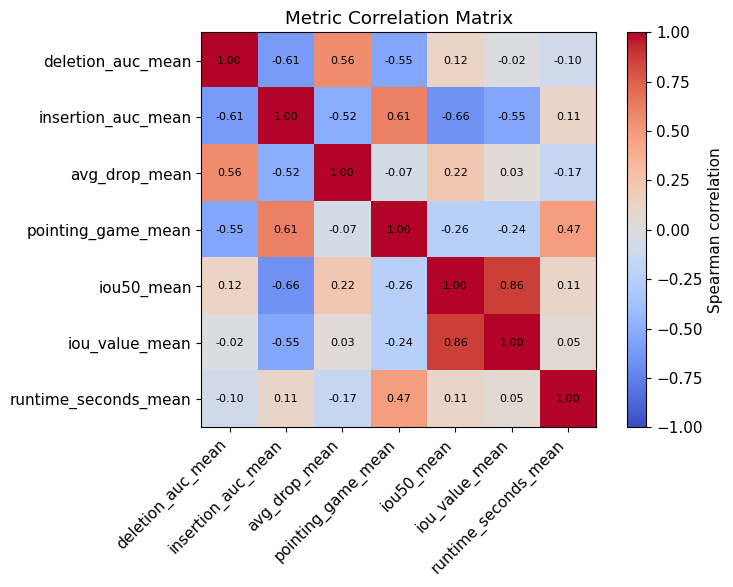

In [8]:
correlation_metrics = [
    "deletion_auc_mean",
    "insertion_auc_mean",
    "avg_drop_mean",
    "pointing_game_mean",
    "iou50_mean",
    "iou_value_mean",
    "runtime_seconds_mean",
]

corr_df = summary_df[correlation_metrics].corr(method="spearman")
corr_df.to_csv(RESULTS_DIR / "metric_correlation_spearman.csv")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_df, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_df.index)), corr_df.index)
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Metric Correlation Matrix")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "metric_correlation_matrix.png", dpi=200)
plt.show()

## Runtime vs Quality

These plots compare runtime with some quality metrics. I use them to see which methods are expensive, cheap, strong, or weak.

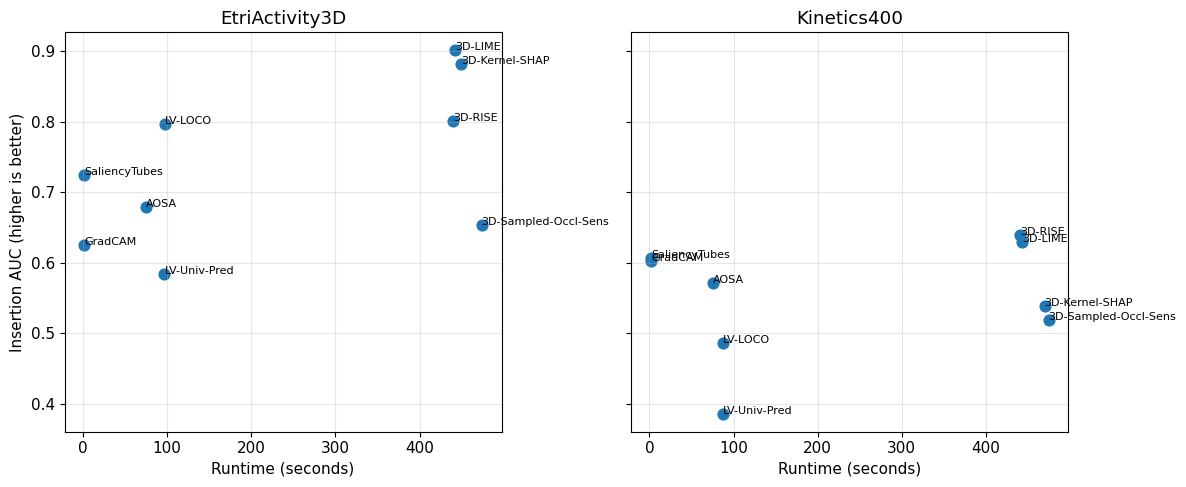

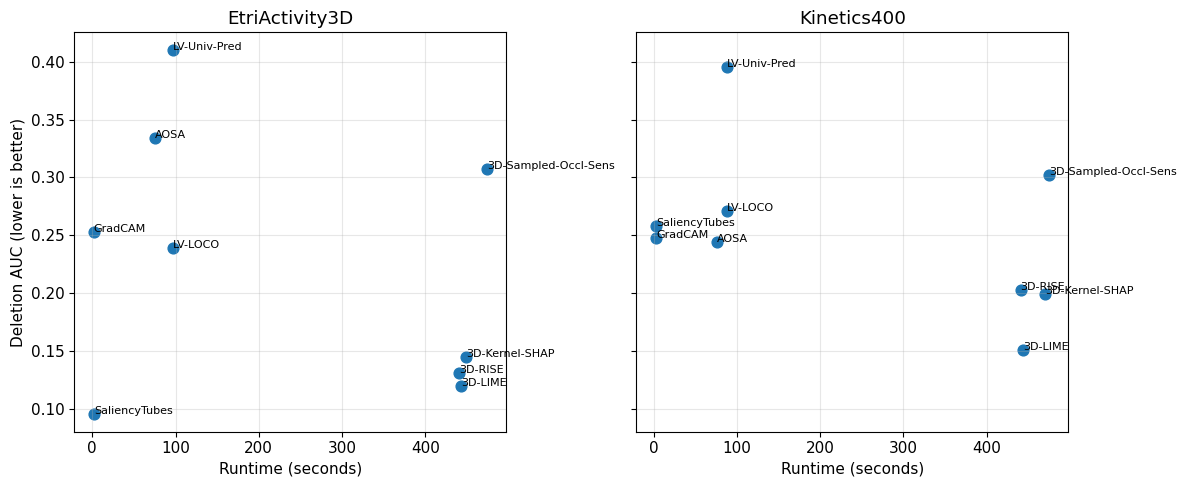

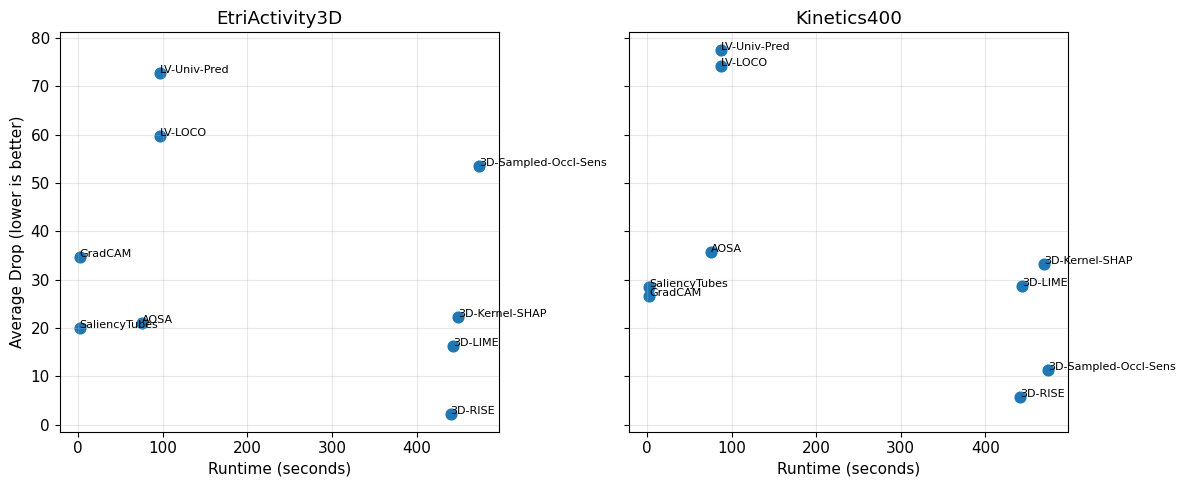

In [9]:
def scatter_runtime_vs(metric, y_label, filename):
    fig, axes = plt.subplots(1, len(DATASETS), figsize=(12, 5), sharey=True)
    if len(DATASETS) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, DATASETS):
        subset = summary_df[summary_df["dataset"] == dataset]
        ax.scatter(subset["runtime_seconds_mean"], subset[f"{metric}_mean"], s=60)
        for _, row in subset.iterrows():
            ax.annotate(row["method_display"], (row["runtime_seconds_mean"], row[f"{metric}_mean"]), fontsize=8)
        ax.set_title(dataset)
        ax.set_xlabel("Runtime (seconds)")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel(y_label)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200)
    plt.show()

scatter_runtime_vs("insertion_auc", "Insertion AUC (higher is better)", "runtime_vs_insertion_auc.png")
scatter_runtime_vs("deletion_auc", "Deletion AUC (lower is better)", "runtime_vs_deletion_auc.png")
scatter_runtime_vs("avg_drop", "Average Drop (lower is better)", "runtime_vs_avg_drop.png")

## Ranking Heatmap

This heatmap summarizes the average rank of each method. Lower values are better.

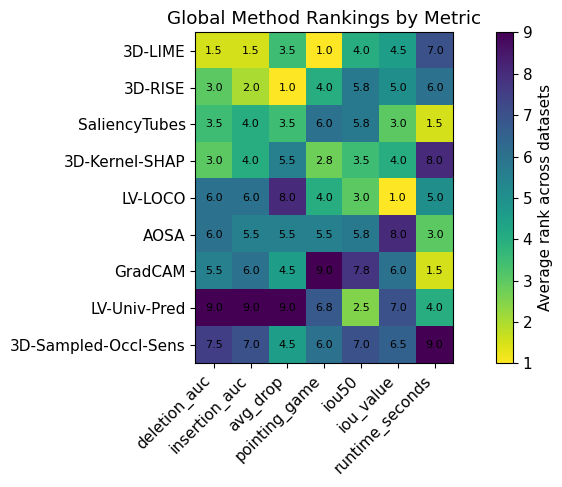

In [10]:
heatmap_df = global_rank.set_index("method_display")[rank_columns]
heatmap_df.columns = [col.replace("rank_", "") for col in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(heatmap_df, cmap="viridis_r")
ax.set_xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_df.index)), heatmap_df.index)
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(j, i, f"{heatmap_df.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Average rank across datasets")
ax.set_title("Global Method Rankings by Metric")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "global_ranking_heatmap.png", dpi=200)
plt.show()

## Files Generated

The notebook saves the tables and figures below so I can reuse them when writing the thesis:

- `metric_summary_by_dataset.csv`: mean and standard deviation per dataset and method.
- `rankings_by_dataset.csv`: rankings for ETRI and Kinetics separately.
- `global_average_rank.csv`: average ranking across both datasets.
- `metric_correlation_spearman.csv`: correlation between metrics.
- Runtime-vs-quality plots: visual comparison of cost and metric performance.

These files are only a first analysis step. The important part is to interpret why methods move up or down depending on the metric.

## Preliminary Interpretation

This is my first reading of the results for the current setup: `TANet`, `EtriActivity3D`, `Kinetics400`, 30 videos per dataset, and 9 XAI methods.

### Which method wins each metric?

The winner changes depending on the metric:

| Metric | Direction | Best method | Comment |
|---|---:|---|---|
| Deletion AUC | Lower | 3D-LIME | Best when important regions are removed. |
| Insertion AUC | Higher | 3D-LIME | Best when important regions are inserted back. |
| Average Drop | Lower | 3D-RISE | Best under the confidence-drop metric. |
| Pointing Game | Higher | 3D-LIME | Best at placing the maximum response inside the box. |
| IoU-50 | Higher | LV-LOCO | Best thresholded overlap with the bounding boxes. |
| IoU Value | Higher | LV-LOCO | Best average overlap with the bounding boxes. |
| Runtime | Lower | GradCAM / SaliencyTubes | Fastest methods in these artifacts. |

`3D-LIME` has the best global average rank, followed by `3D-RISE`, `SaliencyTubes`, and `3D-Kernel-SHAP`. I should be careful with this, because averaging ranks hides the fact that each metric measures something different.

### Do ETRI and Kinetics agree?

They agree in some cases:

- `3D-RISE` is best for Average Drop on both datasets.
- `3D-LIME` is best for Pointing Game on both datasets.
- `LV-LOCO` is best for IoU Value on both datasets.
- `GradCAM` / `SaliencyTubes` are the fastest methods on both datasets.

But the datasets do not fully agree:

- Deletion AUC: `SaliencyTubes` wins on ETRI, while `3D-LIME` wins on Kinetics.
- Insertion AUC: `3D-LIME` wins on ETRI, while `3D-RISE` wins on Kinetics.
- IoU-50: `LV-LOCO` wins on ETRI, while `LV-Univ-Pred` wins on Kinetics.

So the dataset matters. A method that looks best on one dataset is not always best on the other.

### Which metrics disagree most?

The biggest disagreement seems to be between faithfulness metrics and localization metrics.

- Deletion AUC and Insertion AUC give similar rankings.
- Average Drop does not agree well with IoU-50. For example, `3D-RISE` is best for Average Drop, but `LV-LOCO` is better for bounding-box overlap.
- Insertion AUC is negatively correlated with the IoU metrics, so recovering confidence quickly does not necessarily mean the explanation overlaps well with the annotated region.
- Pointing Game and IoU are both localization metrics, but they are not identical. Pointing Game only checks the maximum point, while IoU measures area overlap.

This supports the idea that the conclusion depends on the metric chosen.

### Which methods are fast but weak, or slow but strong?

Fast methods:

- `GradCAM` is very fast, but its overall ranking is weak, especially for localization.
- `SaliencyTubes` is also fast and performs better overall than `GradCAM`.
- `AOSA` is not as fast as GradCAM/SaliencyTubes, but it is still much cheaper than the perturbation-heavy methods.

Slow but stronger methods:

- `3D-LIME` has the best overall rank, but it is expensive.
- `3D-RISE` performs very well for Average Drop and overall ranking, but it is also slow.
- `3D-Kernel-SHAP` is also expensive and competitive, although not as strong overall as `3D-LIME`.

Weak and expensive method:

- `3D-Sampled-Occl-Sens` is one of the slowest methods and has one of the weakest global rankings in this setup.

### Main takeaway

At this point, I would not say that there is a single best explanation method. `3D-LIME` looks strongest overall, but `3D-RISE` is better for Average Drop, `LV-LOCO` is better for bounding-box overlap, and `GradCAM` / `SaliencyTubes` are much faster. This is useful for the thesis because it shows that objective XAI evaluation depends strongly on what we decide to measure.